# Coding Regions
Look at the coding and complementary non-coding regions.

How does information differ between them?

## Data from Ensembl REST
Obtain sequence chunks of species *x* and corresponding binary labels for coding region positions.



In [1]:
import sys
import requests
import random
from collections import Counter
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

#species = 'homo_sapiens'
species = 'mus_musculus'
server = "https://rest.ensembl.org"

### Species info
Get info about the species, namely, the chromosome names.

In [2]:
ext = f"/info/assembly/{species}?"
 
r = requests.get(server+ext, headers={ "Content-Type" : "application/json"})
 
if not r.ok:
  r.raise_for_status()
  sys.exit()
 
res = r.json()
res

{'genebuild_start_date': '2020-08-Ensembl',
 'assembly_name': 'GRCm39',
 'default_coord_system_version': 'GRCm39',
 'assembly_date': '2020-06',
 'genebuild_method': 'full_genebuild',
 'top_level_region': [{'coord_system': 'scaffold',
   'length': 8412,
   'name': 'MU069434.1'},
  {'coord_system': 'scaffold', 'length': 31129, 'name': 'MU069435.1'},
  {'coord_system': 'scaffold', 'name': 'GL456239.1', 'length': 40056},
  {'coord_system': 'scaffold', 'length': 22974, 'name': 'GL456359.1'},
  {'name': 'GL456368.1', 'length': 20208, 'coord_system': 'scaffold'},
  {'coord_system': 'scaffold', 'length': 35240, 'name': 'GL456385.1'},
  {'coord_system': 'scaffold', 'length': 1976, 'name': 'JH584295.1'},
  {'length': 21240, 'name': 'GL456396.1', 'coord_system': 'scaffold'},
  {'coord_system': 'scaffold', 'name': 'GL456370.1', 'length': 26764},
  {'length': 31704, 'name': 'GL456360.1', 'coord_system': 'scaffold'},
  {'coord_system': 'scaffold', 'name': 'GL456382.1', 'length': 23158},
  {'length':

In [3]:
[ print(x) for x in res.keys() ]
#res['karyotype']
chromosomes = {}
for r in res['top_level_region']:
    if r['coord_system'] == 'chromosome':
        chromosomes[r['name']] = r['length']


genebuild_start_date
assembly_name
default_coord_system_version
assembly_date
genebuild_method
top_level_region
karyotype
genebuild_last_geneset_update
golden_path
assembly_accession
genebuild_initial_release_date
coord_system_versions


## Random Sample Generator
A generator of random samples, chosen from some region *r* of size |*r*| in some chromosome. 

In [64]:
random.seed(777)

def get_random_regions(seq_regions: list, sample_len: int, lengths: dict) -> list:
    res = []
    for s in seq_regions:
        
        # get length of this seq region from lengths dict
        s_len = lengths[s]
        # get random region end point
        end = random.randint(sample_len, s_len)
        
        # calculate start point,
        #  use 1-based indexing for Ensembl region query
        start = 1 + end - sample_len
        
        strand = random.choice(['1','-1'])
        res.append({
            'seq_region': s,
            'start': start,
            'end': end,
            'strand': strand
        })

    return res

n = 1000000 # n samples
sample_len = 99 # 99 nc sample size
x = random.choices(*zip(*chromosomes.items()), k=n)

random_regions = get_random_regions(x, sample_len, chromosomes)


In [66]:
lset = set()
for r in random_regions:
    lset.add(r['end'] - r['start'] + 1)

print(f"unique lengths {'; '.join(map(str, lset))}")

unique lengths 99


#### Check the distribution of samples over chromosomes
The counts should be proportional to the chromosome lenghts, os when normalised by the lengths they should be about the same.

In [5]:

# "Eye-ball the distrubution"
c = Counter(x)
df = pd.DataFrame([*chromosomes.items()], columns=['name', 'length'])
df['count'] = df['name'].apply(c.get, c.keys())
df['norm'] = df['count'] * 1000 / df['length']
#df.sort_values('name')
df

,name,length,count,norm
0,MT,16299,3,0.184060
1,Y,91455967,33387,0.365061
2,2,181755017,66731,0.367148
3,4,156860686,57058,0.363750
4,11,121973369,44842,0.367638
5,12,120092757,44035,0.366675
6,17,95294699,34770,0.364868
7,3,159745316,58513,0.366289
8,9,124359700,45500,0.365874
9,16,98008968,36204,0.369395


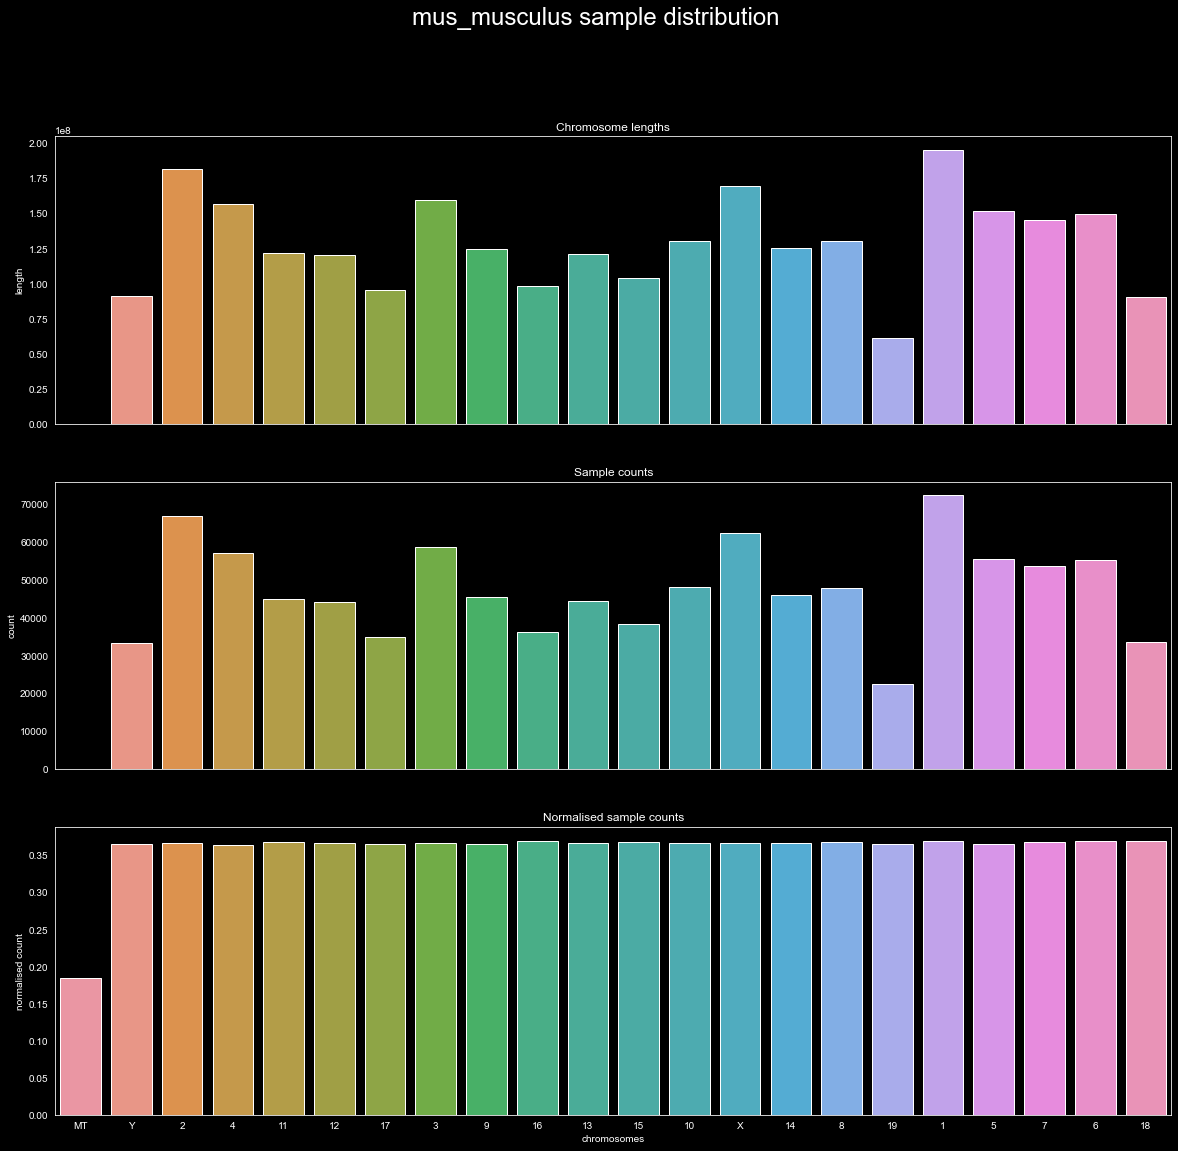

In [6]:

#sns.set_theme(style="darkgrid")
sns.set_style("darkgrid", {'axes.grid' : False})
plt.style.use("dark_background")

fig, ax = plt.subplots(nrows=3, figsize=(20,18), sharex=True)
sns.barplot(ax=ax[0], x='name', y='length', data=df)
ax[0].set_title("Chromosome lengths")
ax[0].set_xlabel("")

sns.barplot(ax=ax[1], x='name', y='count', data=df)
ax[1].set_title("Sample counts")
ax[1].set_xlabel("")

sns.barplot(ax=ax[2], x='name', y='norm', data=df)
ax[2].set_title("Normalised sample counts")
ax[2].set_xlabel("chromosomes")
ax[2].set_ylabel("normalised count")

fig.suptitle(f"{species} sample distribution", size=24)

#[x.grid(b=None, which='major', axis='both') for x in ax]
    
plt.show()



Yay, looks like that worked.

## Sample Region Data
Using the randomly generated region strings, generate query results for each region.

For each region:
 - Sequence
 - all cannonical transcripts
   - **include those partially inside region**
 - Generate labels for positions of
   - exons
   - CDS
   - UTRs ? but these are implied by the exon - CDS difference so duplicate data?
        
        

In [73]:

def get_region_seq(region):
    region_str = ''.join([
        region['seq_region'],
        f":{region['start']}..{region['end']}:",
        region['strand']
    ])
        
    ext = f"/sequence/region/{species}/{region_str}"
    r = requests.get(server+ext, headers={ "Content-Type" : "text/x-fasta"})
 
    if not r.ok:
      r.raise_for_status()
 
    return r.text

test_seq = get_region_seq(random_regions[0])
print(test_seq)

>chromosome:GRCm39:12:14891088:14891186:-1
AAACACCAGGTGTAGATGTGGACTTCCAAATTATAACTTCACTACAGCCATCTCTCATAA
GCTTCACTTTTTTTGTACACTATGGATTTATGTGTTATA



In [75]:
def get_region_labels(region):
    """
    This should return a numpy 2darray of zeros and ones
    with shape (region_length, 2)
    
    A column of exon labels, and a column of CDS labels
    """
    # get transcripts, exons and CDS in region
    
    # filter for those from cannonical transcripts only
    
    # Make labels 2d array
    pass


test_labels = get_region_labels(random_regions[0])
print(test_labels)

None
